**Objective:**
This notebook analyzes raw telemetry data from a gas turbine engine to identify operational correlations and precursor signatures of mechanical faults. The dataset includes high-frequency logs of Turbine Inlet Temperature, RPM, Torque, and Vibrational data.

**Key Analytical Steps:**
1. **Data Ingestion & Cleaning:** Checked for any NaN or Null value in the dataset.
2. **Thermal & Efficiency Profiling:** Mapped the relationship between Temperature and Power Output to establish the baseline operational envelope.
3. **Fault Isolation:** Segmented the data by operational status (`Fault = 0` vs `Fault = 1`) to compare dynamic mechanical responses.

**Preliminary Findings:**
* **Vibrational Signatures:** Initial scatter plot analysis comparing RPM and Torque against Vibrations reveals overlapping clusters. Fault states (1) do not appear exclusively isolated to raw high-magnitude vibrations at the current sample rate.
* **Trend Deviation:** Trend lines applied to the Torque vs. Vibration distributions suggest that while the absolute values overlap, the *operational path* of the turbine differs during a fault state.

**Engineering Next Steps (Future Work):**
Because mechanical faults often manifest in the *rate of change* rather than absolute magnitude, future iterations of this pipeline should feature:
* **Derivative Analysis:** Calculating `d(Vibration)/dt` to isolate sudden mechanical shocks.
* **Frequency Domain Analysis:** Applying Fast Fourier Transforms (FFT) to the vibration data to look for specific harmonic frequencies that can lead to failure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('gas_turbine_fault_detection.csv')
print("Total columns: ", len(df.columns))
print("Column Names: ")
for col in df.columns:
    print("----> " + col)

print("\nChecking if any column has null values: \n")
print(df.isnull().any())

Total columns:  10
Column Names: 
----> Temperature (°C)
----> RPM
----> Torque (Nm)
----> Vibrations (mm/s)
----> Power Output (MW)
----> Fuel Flow Rate (kg/s)
----> Air Pressure (kPa)
----> Exhaust Gas Temperature (°C)
----> Oil Temperature (°C)
----> Fault

Checking if any column has null values: 

Temperature (°C)                False
RPM                             False
Torque (Nm)                     False
Vibrations (mm/s)               False
Power Output (MW)               False
Fuel Flow Rate (kg/s)           False
Air Pressure (kPa)              False
Exhaust Gas Temperature (°C)    False
Oil Temperature (°C)            False
Fault                           False
dtype: bool


In [3]:
abs_max_temp=df['Temperature (°C)'].max()
print("Absolute Maximum Temperature Reached: ", abs_max_temp)

Absolute Maximum Temperature Reached:  1092.6365745327362


In [4]:
danger_zone=df[(df['Temperature (°C)']>df['Temperature (°C)'].quantile(.90)) & (df['RPM']>df['RPM'].mean())]
print("Number of stress test instances: ", len(danger_zone))
print("Potentially stressed instances: \n", danger_zone[['Temperature (°C)', 'RPM', 'Power Output (MW)', 'Fault']])

Number of stress test instances:  76
Potentially stressed instances: 
       Temperature (°C)           RPM  Power Output (MW)  Fault
6           978.960641  16006.693624          90.272355      0
31          992.613909  15134.296139          80.426614      0
65          967.812001  15851.107472         100.376966      0
71          976.901828  15190.579192          74.464504      1
73          978.232183  15336.590676          96.739875      0
...                ...           ...                ...    ...
1312        969.510377  15311.034995         101.514074      1
1330        976.537542  15312.754008          86.527461      0
1333        974.536307  15061.773848          92.665179      0
1374        973.558516  15314.764792         117.509259      0
1379        991.300486  15410.172006          92.828181      0

[76 rows x 4 columns]


In [5]:
grouped_faults = df.groupby('Fault').mean()
print("\nAverage values for each fault type: \n", grouped_faults)


Average values for each fault type: 
        Temperature (°C)           RPM  Torque (Nm)  Vibrations (mm/s)  \
Fault                                                                   
0            903.856940  15028.607248  3495.146442           1.985267   
1            896.574708  15008.988821  3493.900160           1.964711   

       Power Output (MW)  Fuel Flow Rate (kg/s)  Air Pressure (kPa)  \
Fault                                                                 
0              99.588273               2.508968          150.071272   
1              99.291367               2.497955          150.884269   

       Exhaust Gas Temperature (°C)  Oil Temperature (°C)  
Fault                                                      
0                        498.012155            120.087195  
1                        500.794399            120.004777  


In [6]:
df['Temp_Kelvin']= df['Temperature (°C)'] + 273.15
df['Pressure_Ratio']= df['Air Pressure (kPa)'] / df['Air Pressure (kPa)'].min()

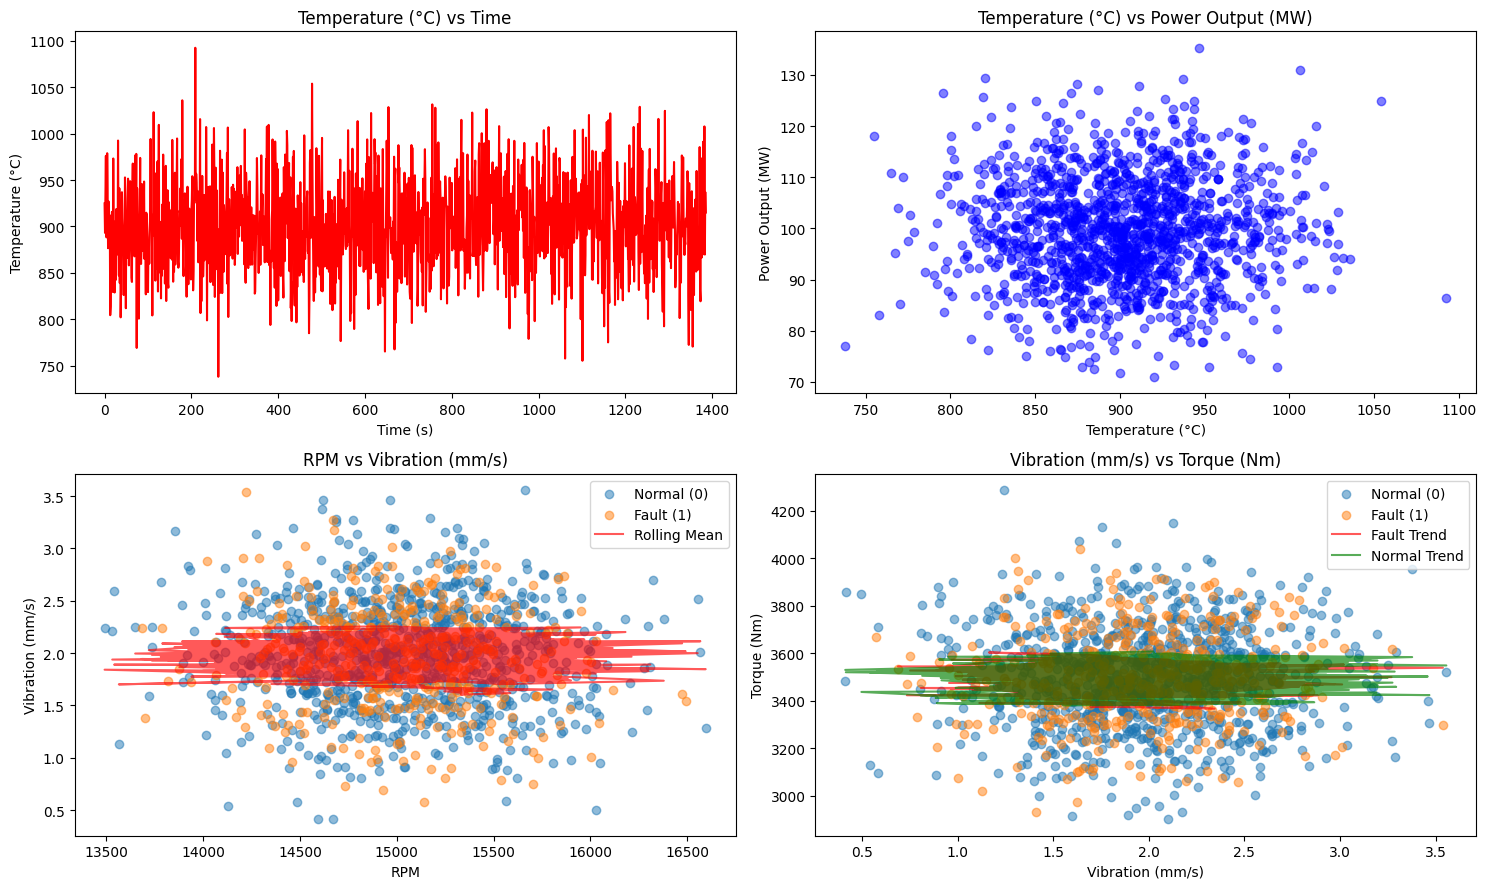

In [7]:
main_plot=plt.figure(figsize=(15,9))
plot1=main_plot.add_subplot(2,2,1)

plot1.plot(df.index, df['Temperature (°C)'], color='red')
plot1.set_title("Temperature (°C) vs Time")
plot1.set_xlabel("Time (s)")
plot1.set_ylabel("Temperature (°C)")    
plot1.plot()

plot2=main_plot.add_subplot(2,2,2)
plot2.scatter(df['Temperature (°C)'], df['Power Output (MW)'], color='blue', alpha=0.5)
plot2.set_title("Temperature (°C) vs Power Output (MW)")
plot2.set_xlabel("Temperature (°C)")
plot2.set_ylabel("Power Output (MW)")
plot2.plot()

plot3 = main_plot.add_subplot(2,2,3)
plot3.scatter(df[df['Fault']==0]['RPM'], df[df['Fault']==0]['Vibrations (mm/s)'], alpha=0.5, label='Normal (0)')
plot3.scatter(df[df['Fault']==1]['RPM'], df[df['Fault']==1]['Vibrations (mm/s)'], alpha=0.5, label='Fault (1)')
plot3.plot(df['RPM'], df['Vibrations (mm/s)'].rolling(window=20).mean(), color='red', linewidth=1.5, alpha=0.65, label='Rolling Mean')
plot3.set_title("RPM vs Vibration (mm/s)")
plot3.set_xlabel("RPM")
plot3.set_ylabel("Vibration (mm/s)")
plot3.legend()

plot4 = main_plot.add_subplot(2,2,4)
plot4.scatter(df[df['Fault']==0]['Vibrations (mm/s)'], df[df['Fault']==0]['Torque (Nm)'], alpha=0.5, label='Normal (0)')
plot4.scatter(df[df['Fault']==1]['Vibrations (mm/s)'], df[df['Fault']==1]['Torque (Nm)'], alpha=0.5, label='Fault (1)')
plot4.plot(df[df['Fault']==1]['Vibrations (mm/s)'], df[df['Fault']==1]['Torque (Nm)'].rolling(window=20).mean(), color='red', linewidth=1.5, alpha=0.65, label='Fault Trend')
plot4.plot(df[df['Fault']==0]['Vibrations (mm/s)'], df[df['Fault']==0]['Torque (Nm)'].rolling(window=20).mean(), color='green', linewidth=1.5, alpha=0.65, label='Normal Trend')
plot4.set_title("Vibration (mm/s) vs Torque (Nm)")
plot4.set_xlabel("Vibration (mm/s)")
plot4.set_ylabel("Torque (Nm)")
plot4.legend()

plt.tight_layout()




In [8]:
df['Vib_Derivative_(mm/s**2)'] = df['Vibrations (mm/s)'].diff()
df.dropna(axis=0,inplace=True)


Standard Deviation of Vibrational Derivative about 0 (mm/s^2) for Normal(0):  0.6965594444802551
Standard Deviation of Vibrational Derivative about 0 (mm/s^2) for Fault(1):  0.7154029904072672


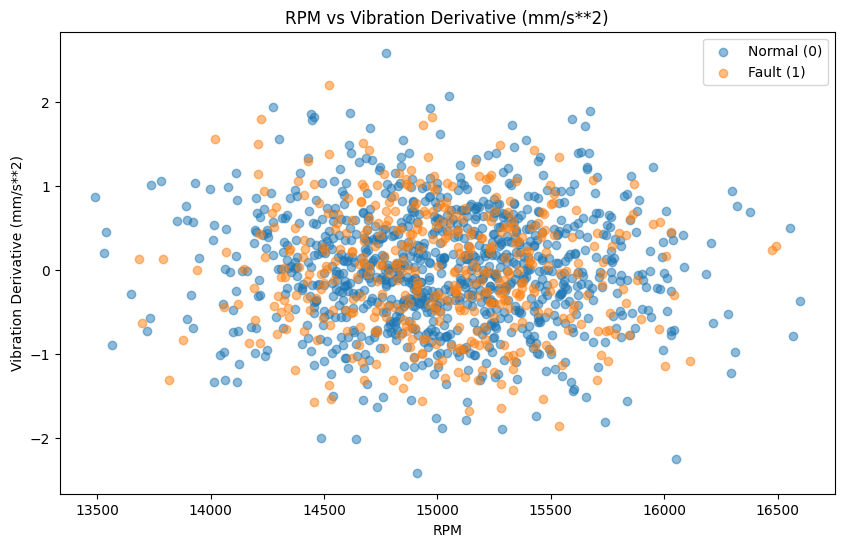

In [13]:
second_plot=plt.figure(figsize=(10,6))
plot5=second_plot.add_subplot(1,1,1)

plot5.scatter(y=df[df['Fault']==0]['Vib_Derivative_(mm/s**2)'], x=df[df['Fault']==0]['RPM'], alpha=0.5, label='Normal (0)')
plot5.scatter(y=df[df['Fault']==1]['Vib_Derivative_(mm/s**2)'], x=df[df['Fault']==1]['RPM'], alpha=0.5, label='Fault (1)')
plot5.set_title("RPM vs Vibration Derivative (mm/s**2)")
plot5.set_xlabel("RPM")
plot5.set_ylabel("Vibration Derivative (mm/s**2)")
plot5.legend()

print("Standard Deviation of Vibrational Derivative about 0 (mm/s^2) for Normal(0): ",df[df['Fault']==0]['Vib_Derivative_(mm/s**2)'].std())
print("Standard Deviation of Vibrational Derivative about 0 (mm/s^2) for Fault(1): ",df[df['Fault']==1]['Vib_Derivative_(mm/s**2)'].std())


